# Pareto Conditional Analysis
**Date:** 2026-05-05  
**Data:** `pareto_results_init_10000samples/pareto_results.csv` (10,000 log-uniform samples)

Four complementary analyses to understand the lambda → objective mapping without Sobol:

1. **Conditional distributions** — which log-lambdas differ between feasible and infeasible points?
2. **Decision tree on feasibility** — explicit threshold rules that define the feasible region
3. **Lambda ratios vs Pareto position** — within feasible points, what ratio drives obj_hom vs obj_kin?
4. **2D regime maps** — 2D projection of log-lambda space colored by toya_r², reveals the feasibility "island"

**Feasibility threshold:** `toya_r_squared > 0.5`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

os.chdir(os.path.expanduser('~/dev/vEcoli'))

sns.set_theme(style='whitegrid', font_scale=1.1)
FEASIBILITY_THRESHOLD = 0.5
LAMBDA_COLS = ['lambda_hom', 'lambda_sec', 'lambda_eff', 'lambda_kin', 'lambda_div']
LAMBDA_LABELS = [r'$\lambda_{hom}$', r'$\lambda_{sec}$', r'$\lambda_{eff}$',
                 r'$\lambda_{kin}$', r'$\lambda_{div}$']
OBJ_COLS = ['obj_homeo', 'obj_kin', 'obj_eff', 'obj_sec', 'obj_div']

In [2]:
CSV_PATH = 'notebooks/Heena notebooks/Metabolism_New Genes/pareto_results_init_10000samples/pareto_results.csv'
# To pool multiple CSVs uncomment below and add paths to EXTRA_CSVS:
# EXTRA_CSVS = ['notebooks/Heena notebooks/Metabolism_New Genes/dep/pareto_results_2000samples/pareto_results.csv']
# df = pd.concat([pd.read_csv(CSV_PATH)] + [pd.read_csv(p) for p in EXTRA_CSVS], ignore_index=True)
df = pd.read_csv(CSV_PATH)

# Log-transform the lambdas — all analyses run in log10 space
for col in LAMBDA_COLS:
    df[f'log_{col}'] = np.log10(df[col])
LOG_LAMBDA_COLS = [f'log_{c}' for c in LAMBDA_COLS]

df['feasible'] = df['toya_r_squared'] > FEASIBILITY_THRESHOLD
df['feasible_label'] = df['feasible'].map({True: 'Feasible', False: 'Infeasible'})

feasible_df = df[df['feasible']].copy()
infeasible_df = df[~df['feasible']].copy()

print(f'Total samples : {len(df):,}')
print(f'Feasible      : {len(feasible_df):,} ({100*len(feasible_df)/len(df):.1f}%)')
print(f'Infeasible    : {len(infeasible_df):,} ({100*len(infeasible_df)/len(df):.1f}%)')
print(f'toya_r² range : [{df.toya_r_squared.min():.3f}, {df.toya_r_squared.max():.3f}]')

Total samples : 10,000
Feasible      : 1,319 (13.2%)
Infeasible    : 8,681 (86.8%)
toya_r² range : [-86.568, 0.684]


---
## Analysis 1 — Conditional Distributions: Feasible vs Infeasible

Violin plots show the full distribution of each log10(lambda) split by feasibility.
A lambda with **very different distributions** between the two groups is a strong gate for feasibility.
A lambda with **overlapping distributions** has little individual effect on feasibility.

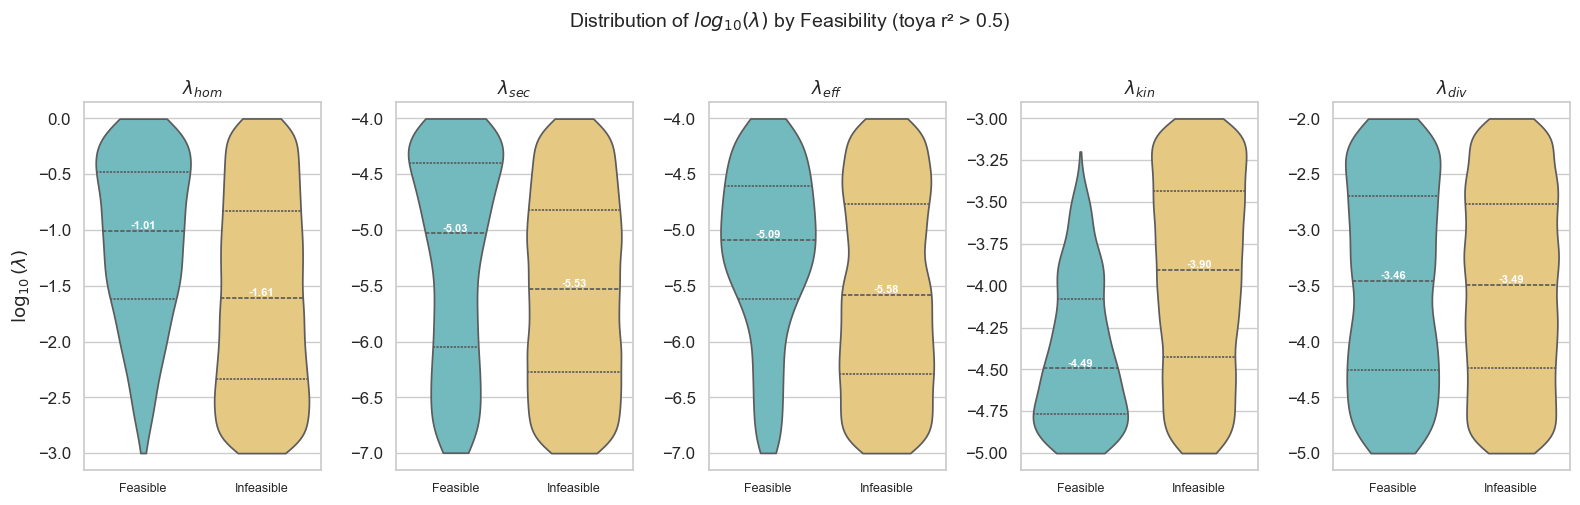

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5), sharey=False)
palette = {'Feasible': '#66c5cc', 'Infeasible': '#f6cf71'}

for ax, log_col, label in zip(axes, LOG_LAMBDA_COLS, LAMBDA_LABELS):
    sns.violinplot(
        data=df, x='feasible_label', y=log_col,
        palette=palette, hue='feasible_label', order=['Feasible', 'Infeasible'],
        inner='quartile', ax=ax, cut=0,
    )
    # Overlay medians
    for i, grp in enumerate(['Feasible', 'Infeasible']):
        med = df.loc[df['feasible_label'] == grp, log_col].median()
        ax.text(i, med, f'{med:.2f}', ha='center', va='bottom', fontsize=8,
                fontweight='bold', color='white')
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel(r'$\log_{10}(\lambda)$' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle(r'Distribution of $log_{10}(λ)$ by Feasibility (toya r² > 0.5)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('notebooks/Heena notebooks/Metabolism_New Genes/out/objective_weights/pareto_conditional_analysis/log_lambda_violin_plots.svg', dpi=600)
plt.show()

In [12]:
# Quantify the shift: how many std-deviations apart are the feasible/infeasible medians?
print('Lambda separation between feasible and infeasible medians:')
print(f'{"Lambda":<20} {"Feasible median":>18} {"Infeasible median":>20} {"Shift (feas - inf)":>20}')
print('-' * 80)
for log_col, label in zip(LOG_LAMBDA_COLS, LAMBDA_COLS):
    feas_med = feasible_df[log_col].median()
    inf_med  = infeasible_df[log_col].median()
    shift    = feas_med - inf_med
    print(f'{label:<20} {feas_med:>18.3f} {inf_med:>20.3f} {shift:>20.3f}')

Lambda separation between feasible and infeasible medians:
Lambda                  Feasible median    Infeasible median   Shift (feas - inf)
--------------------------------------------------------------------------------
lambda_hom                       -1.010               -1.609                0.599
lambda_sec                       -5.030               -5.530                0.500
lambda_eff                       -5.088               -5.582                0.494
lambda_kin                       -4.494               -3.905               -0.589
lambda_div                       -3.457               -3.495                0.037


---
## Analysis 2 — Decision Tree on Feasibility

A shallow decision tree (depth ≤ 4) on the 5 log-lambdas learns explicit threshold rules
that separate feasible from infeasible points. Unlike correlation, it captures:
- **Non-linear thresholds** (e.g., feasibility only if log_lambda_kin < -3.5)
- **Conjunctive rules** (feasible if condition A AND condition B)

Depth 4 → at most 16 leaf rules. We print the full text and visualize the tree.

In [13]:
X = df[LOG_LAMBDA_COLS].values
y = df['feasible'].astype(int).values

tree = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
tree.fit(X, y)

preds = tree.predict(X)
print('In-sample classification report:')
print(classification_report(y, preds, target_names=['Infeasible', 'Feasible']))

# Feature importance
print('\nFeature importances (Gini):')
for col, imp in sorted(zip(LAMBDA_COLS, tree.feature_importances_), key=lambda x: -x[1]):
    bar = '█' * int(imp * 50)
    print(f'  {col:<20} {imp:.4f}  {bar}')

In-sample classification report:
              precision    recall  f1-score   support

  Infeasible       0.97      0.78      0.87      8681
    Feasible       0.38      0.87      0.53      1319

    accuracy                           0.80     10000
   macro avg       0.68      0.83      0.70     10000
weighted avg       0.90      0.80      0.82     10000


Feature importances (Gini):
  lambda_kin           0.3540  █████████████████
  lambda_eff           0.3114  ███████████████
  lambda_sec           0.1919  █████████
  lambda_hom           0.1427  ███████
  lambda_div           0.0000  


In [14]:
# Human-readable text rules
feature_names = [f'log10({c})' for c in LAMBDA_COLS]
print('Decision tree rules (depth ≤ 4):')
print('=' * 60)
print(export_text(tree, feature_names=feature_names))

Decision tree rules (depth ≤ 4):
|--- log10(lambda_kin) <= -3.81
|   |--- log10(lambda_hom) <= -2.11
|   |   |--- log10(lambda_eff) <= -4.57
|   |   |   |--- log10(lambda_eff) <= -5.95
|   |   |   |   |--- class: 0
|   |   |   |--- log10(lambda_eff) >  -5.95
|   |   |   |   |--- class: 0
|   |   |--- log10(lambda_eff) >  -4.57
|   |   |   |--- class: 0
|   |--- log10(lambda_hom) >  -2.11
|   |   |--- log10(lambda_eff) <= -5.59
|   |   |   |--- log10(lambda_sec) <= -4.98
|   |   |   |   |--- class: 0
|   |   |   |--- log10(lambda_sec) >  -4.98
|   |   |   |   |--- class: 1
|   |   |--- log10(lambda_eff) >  -5.59
|   |   |   |--- log10(lambda_eff) <= -4.35
|   |   |   |   |--- class: 1
|   |   |   |--- log10(lambda_eff) >  -4.35
|   |   |   |   |--- class: 1
|--- log10(lambda_kin) >  -3.81
|   |--- log10(lambda_eff) <= -4.41
|   |   |--- log10(lambda_eff) <= -4.58
|   |   |   |--- class: 0
|   |   |--- log10(lambda_eff) >  -4.58
|   |   |   |--- log10(lambda_kin) <= -3.55
|   |   |   |  

/var/folders/s9/gn2yly0s7rzgcc2xyvt7nsxm0000gr/T/ipykernel_31326/2604724620.py:10: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s9/gn2yly0s7rzgcc2xyvt7nsxm0000gr/T/ipykernel_31326/2604724620.py:10: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/heenasaqib/dev/vEcoli/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/heenasaqib/dev/vEcoli/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


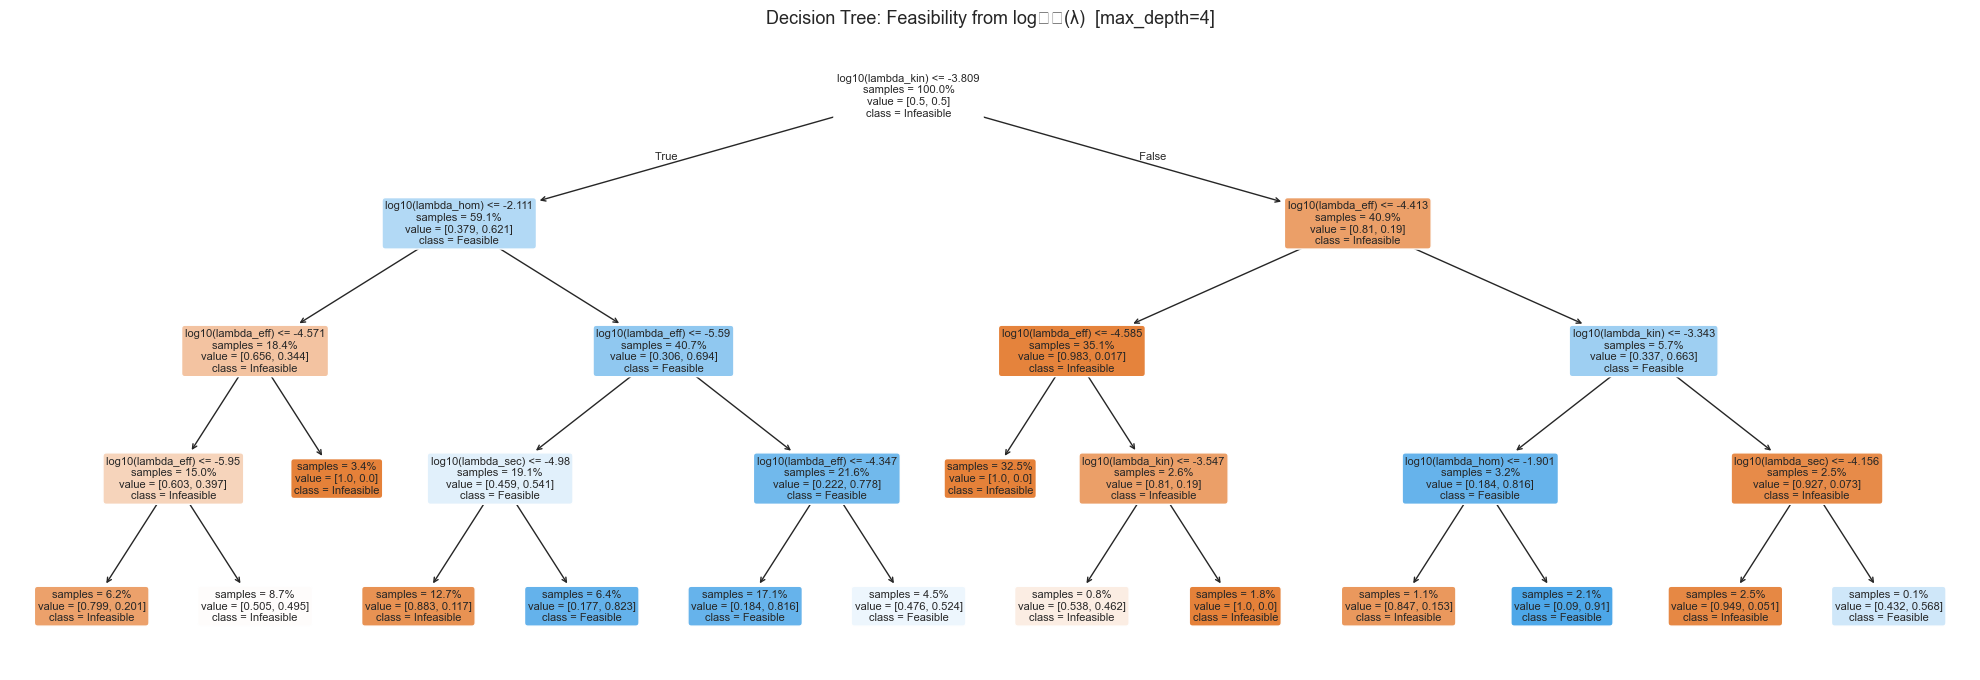

In [15]:
fig, ax = plt.subplots(figsize=(20, 7))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=['Infeasible', 'Feasible'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    impurity=False, proportion=True,
)
ax.set_title('Decision Tree: Feasibility from log₁₀(λ)  [max_depth=4]', fontsize=13)
plt.tight_layout()
plt.show()

---
## Analysis 3 — Lambda Ratios vs Pareto Position (Feasible Points Only)

Within the feasible set, we want to know: **what determines whether you sit toward low obj_hom
or low obj_kin on the Pareto curve?**

The ratio `log10(lambda_hom / lambda_kin)` directly encodes how much the optimizer is told
to care about homeostasis *relative* to kinetics. We check whether this (and other ratios)
correlates with the actual Pareto position.

In [16]:
# Compute key ratios (all in log10 space = differences of log-lambdas)
fdf = feasible_df.copy()
fdf['ratio_hom_kin']  = fdf['log_lambda_hom'] - fdf['log_lambda_kin']   # log10(lam_hom/lam_kin)
fdf['ratio_hom_eff']  = fdf['log_lambda_hom'] - fdf['log_lambda_eff']
fdf['ratio_hom_sec']  = fdf['log_lambda_hom'] - fdf['log_lambda_sec']
fdf['ratio_kin_eff']  = fdf['log_lambda_kin'] - fdf['log_lambda_eff']

# Pareto position: signed distance along the frontier, normalized
# We use (obj_hom_w - obj_kin_w) as a proxy: positive = leaning toward high hom cost
fdf['pareto_lean'] = fdf['obj_hom_w'] - fdf['obj_kin_w']

ratios = ['ratio_hom_kin', 'ratio_hom_eff', 'ratio_hom_sec', 'ratio_kin_eff']
ratio_labels = [
    r'$\log_{10}(\lambda_{hom}/\lambda_{kin})$',
    r'$\log_{10}(\lambda_{hom}/\lambda_{eff})$',
    r'$\log_{10}(\lambda_{hom}/\lambda_{sec})$',
    r'$\log_{10}(\lambda_{kin}/\lambda_{eff})$',
]

print('Pearson r with obj_homeo (lower = better homeostasis):')
for r, rl in zip(ratios, ratio_labels):
    corr_hom = fdf[r].corr(fdf['obj_homeo'])
    corr_kin = fdf[r].corr(fdf['obj_kin'])
    print(f'  {r:<20}  r(obj_hom)={corr_hom:+.3f}   r(obj_kin)={corr_kin:+.3f}')

Pearson r with obj_homeo (lower = better homeostasis):
  ratio_hom_kin         r(obj_hom)=-0.587   r(obj_kin)=+0.260
  ratio_hom_eff         r(obj_hom)=-0.479   r(obj_kin)=-0.075
  ratio_hom_sec         r(obj_hom)=-0.198   r(obj_kin)=+0.237
  ratio_kin_eff         r(obj_hom)=+0.011   r(obj_kin)=-0.494


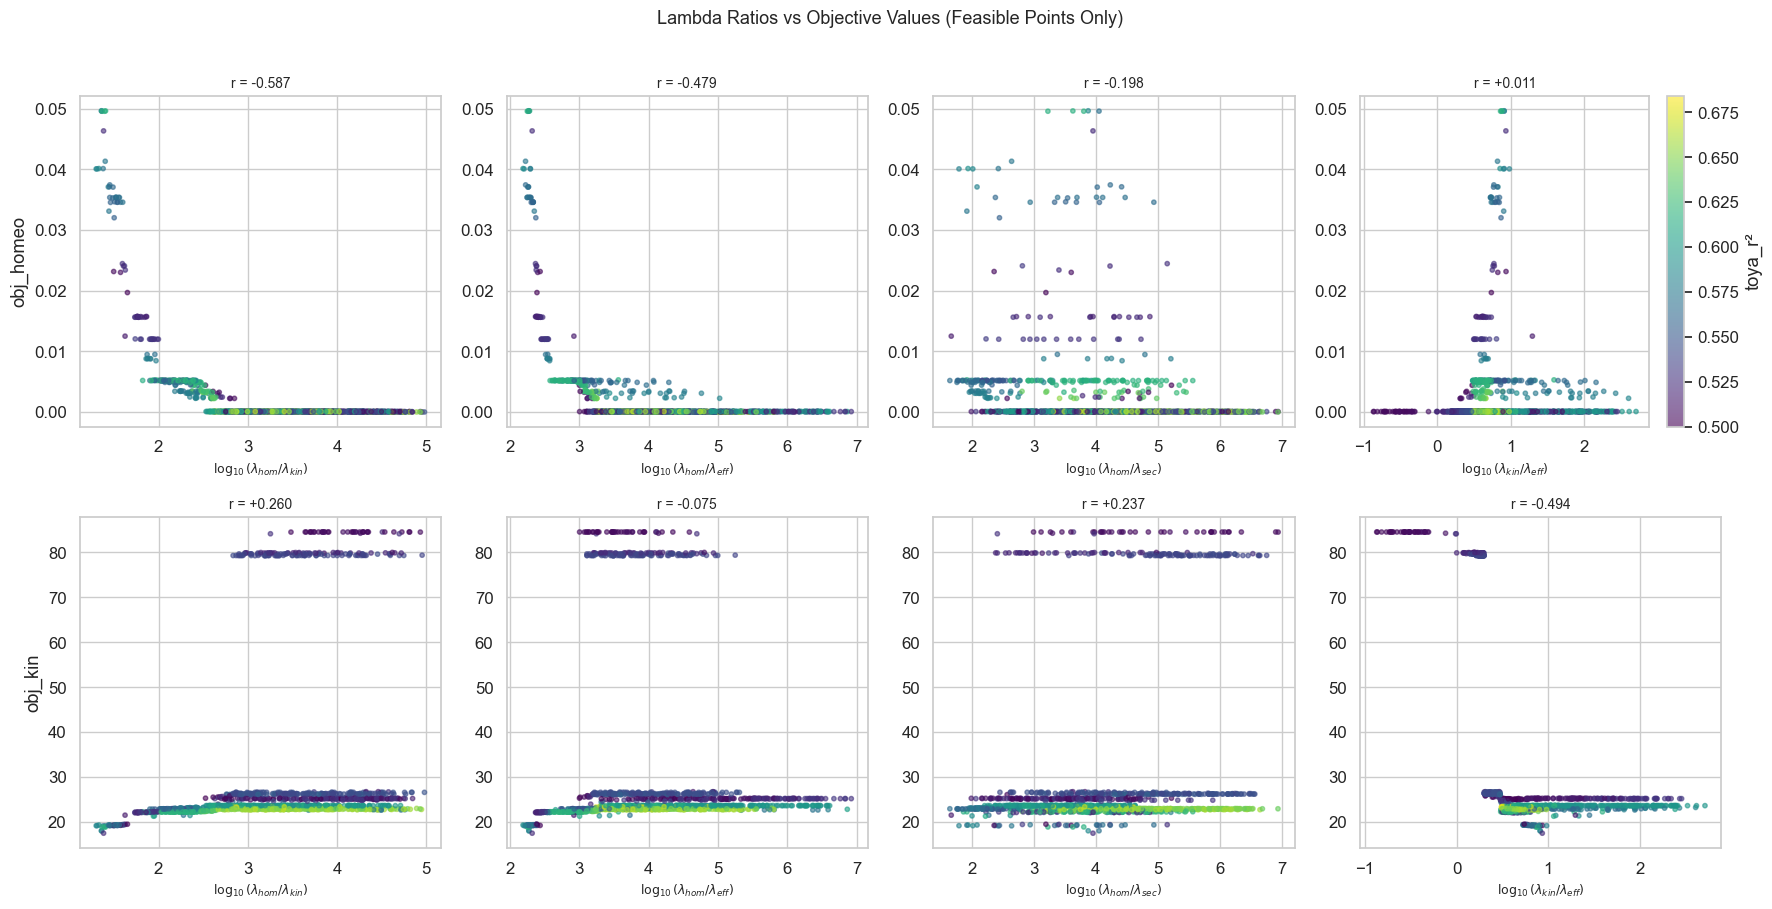

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
targets = ['obj_homeo', 'obj_kin']
target_labels = ['obj_homeo (lower = better)', 'obj_kin (lower = better)']

for row_idx, (target, tlabel) in enumerate(zip(targets, target_labels)):
    for col_idx, (ratio, rlabel) in enumerate(zip(ratios, ratio_labels)):
        ax = axes[row_idx, col_idx]
        sc = ax.scatter(
            fdf[ratio], fdf[target],
            c=fdf['toya_r_squared'], cmap='viridis',
            s=10, alpha=0.6, vmin=0.5, vmax=fdf['toya_r_squared'].max(),
        )
        r = fdf[ratio].corr(fdf[target])
        ax.set_xlabel(rlabel, fontsize=9)
        ax.set_ylabel(target if col_idx == 0 else '')
        ax.set_title(f'r = {r:+.3f}', fontsize=10)
        if row_idx == 0 and col_idx == 3:
            plt.colorbar(sc, ax=ax, label='toya_r²')

fig.suptitle('Lambda Ratios vs Objective Values (Feasible Points Only)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Most correlated ratio with obj_homeo: ratio_hom_kin (r=-0.587)


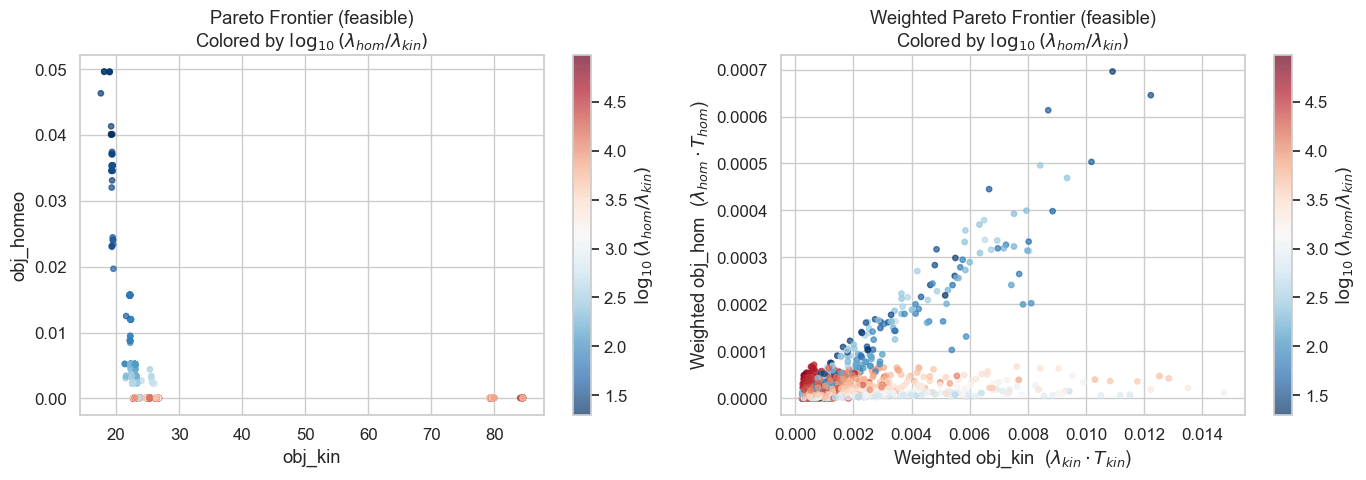

In [20]:
# Focus: obj_homeo vs obj_kin scatter, colored by the dominant ratio
# This shows the Pareto frontier and which ratio controls position on it
best_ratio = max(ratios, key=lambda r: abs(fdf[r].corr(fdf['obj_homeo'])))
best_ratio_label = ratio_labels[ratios.index(best_ratio)]
print(f'Most correlated ratio with obj_homeo: {best_ratio} (r={fdf[best_ratio].corr(fdf["obj_homeo"]):+.3f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: obj_hom vs obj_kin colored by dominant ratio
ax = axes[0]
sc = ax.scatter(
    fdf['obj_kin'], fdf['obj_homeo'],
    c=fdf[best_ratio], cmap='RdBu_r',
    s=15, alpha=0.7,
)
plt.colorbar(sc, ax=ax, label=best_ratio_label)
ax.set_xlabel('obj_kin')
ax.set_ylabel('obj_homeo')
ax.set_title(f'Pareto Frontier (feasible)\nColored by {best_ratio_label}')

# Right: weighted versions (what the optimizer actually sees)
ax = axes[1]
sc = ax.scatter(
    fdf['obj_kin_w'], fdf['obj_hom_w'],
    c=fdf[best_ratio], cmap='RdBu_r',
    s=15, alpha=0.7,
)
plt.colorbar(sc, ax=ax, label=best_ratio_label)
ax.set_xlabel(r'Weighted obj_kin  ($\lambda_{kin} \cdot T_{kin}$)')
ax.set_ylabel(r'Weighted obj_hom  ($\lambda_{hom} \cdot T_{hom}$)')
ax.set_title(f'Weighted Pareto Frontier (feasible)\nColored by {best_ratio_label}')

plt.tight_layout()
plt.savefig('notebooks/Heena notebooks/Metabolism_New Genes/out/objective_weights/pareto_conditional_analysis/pareto_scatter_home_kin_ratio.svg', dpi=600)
plt.show()

---
## Analysis 4 — 2D Regime Maps

Scatter plots of every pair of log-lambdas, colored by `toya_r²`. This reveals:
- The shape and location of the feasible "island" in 2D projections
- Which lambda *pairs* jointly gate feasibility (interaction effects)
- Whether the feasible region is convex/simple or fragmented in each 2D slice

/var/folders/s9/gn2yly0s7rzgcc2xyvt7nsxm0000gr/T/ipykernel_31326/2551698257.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


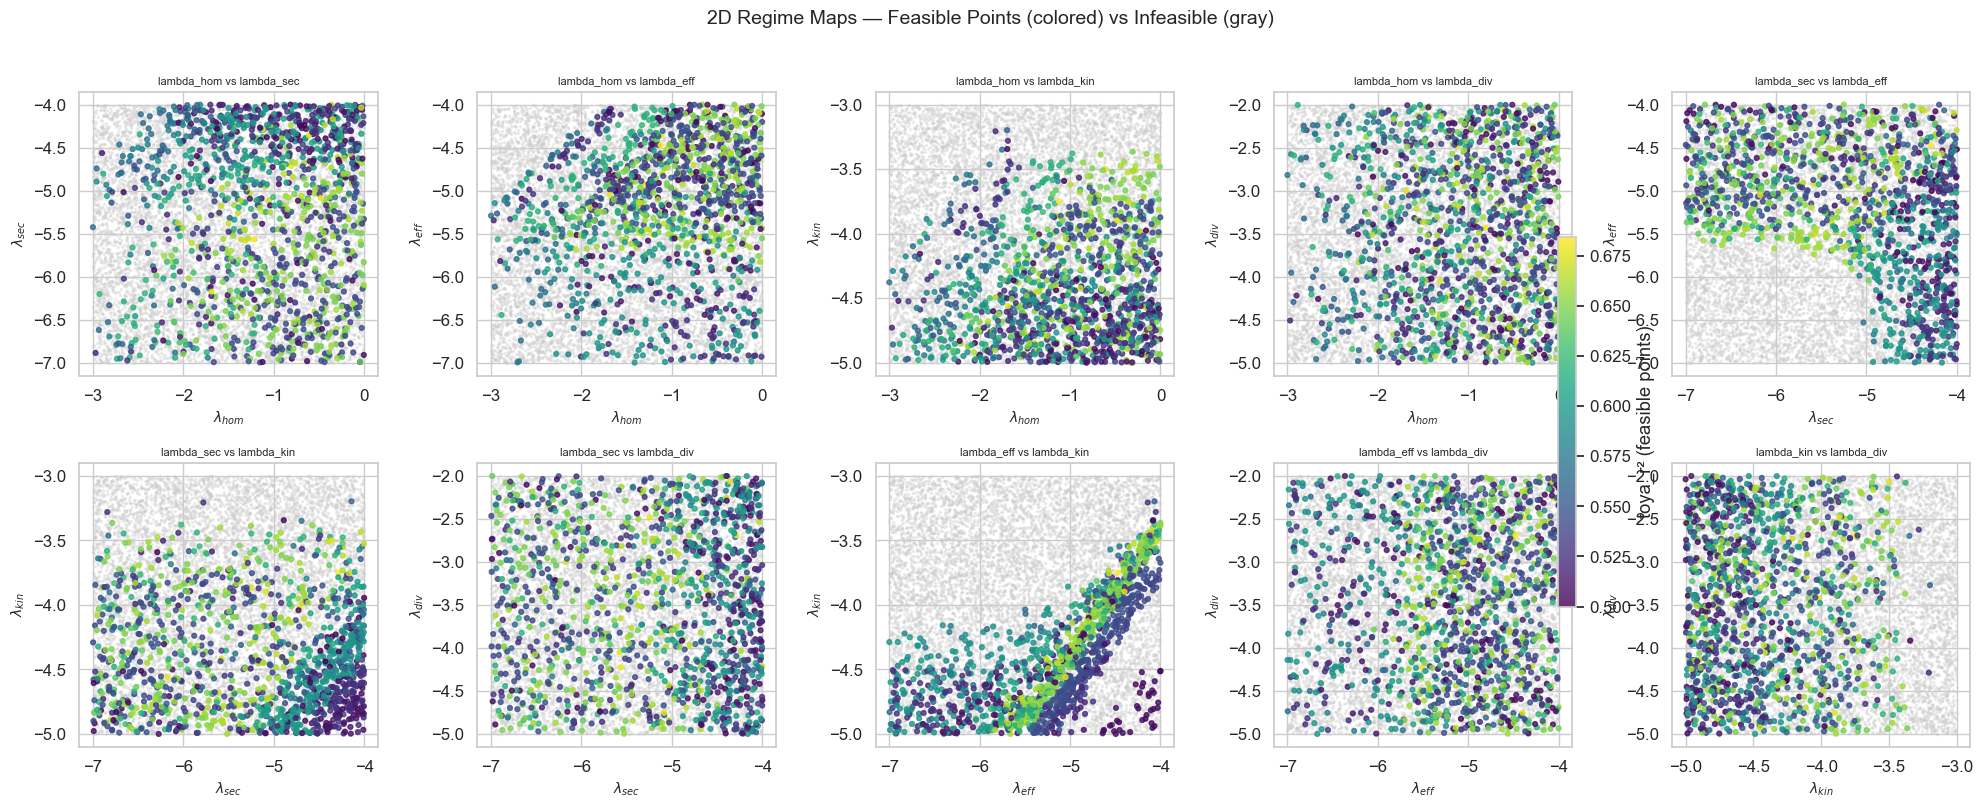

In [22]:
# All 10 pairs of 5 lambdas
from itertools import combinations

pairs = list(combinations(range(5), 2))
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Use a diverging colormap anchored at 0.5 (the feasibility threshold)
vmin, vmax = df['toya_r_squared'].clip(-5, None).min(), df['toya_r_squared'].max()
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.5, vmax=vmax)

for ax, (i, j) in zip(axes, pairs):
    xi, xj = LOG_LAMBDA_COLS[i], LOG_LAMBDA_COLS[j]
    # Plot infeasible first (gray background), then feasible on top
    ax.scatter(
        infeasible_df[xi], infeasible_df[xj],
        c='#cccccc', s=2, alpha=0.3, rasterized=True,
    )
    sc = ax.scatter(
        feasible_df[xi], feasible_df[xj],
        c=feasible_df['toya_r_squared'], cmap='viridis',
        s=12, alpha=0.8, vmin=0.5, vmax=vmax,
    )
    ax.set_xlabel(LAMBDA_LABELS[i], fontsize=10)
    ax.set_ylabel(LAMBDA_LABELS[j], fontsize=10)
    ax.set_title(f'{LAMBDA_COLS[i]} vs {LAMBDA_COLS[j]}', fontsize=8)

# Hide unused axes
for ax in axes[len(pairs):]:
    ax.set_visible(False)

fig.colorbar(sc, ax=axes[:len(pairs)], label='toya_r² (feasible points)', shrink=0.6)
fig.suptitle('2D Regime Maps — Feasible Points (colored) vs Infeasible (gray)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('notebooks/Heena notebooks/Metabolism_New Genes/out/objective_weights/pareto_conditional_analysis/lamda_pairwise_scatter_feasibility.png', dpi=600)
plt.show()

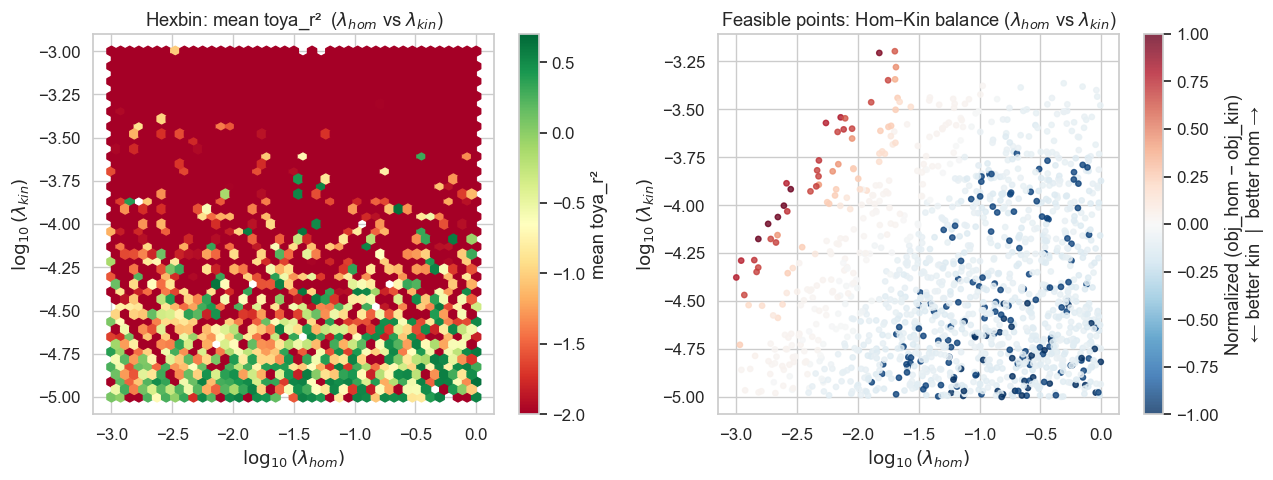

In [23]:
# Zoom in: the dominant pair lambda_hom vs lambda_kin with a hexbin density
# to avoid overplotting at high density
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: all points, hexbin colored by mean toya_r²
ax = axes[0]
hb = ax.hexbin(
    df['log_lambda_hom'], df['log_lambda_kin'],
    C=df['toya_r_squared'].clip(-5, None),
    gridsize=40, cmap='RdYlGn', reduce_C_function=np.mean,
    vmin=-2, vmax=0.7,
)
plt.colorbar(hb, ax=ax, label='mean toya_r²')
ax.set_xlabel(r'$\log_{10}(\lambda_{hom})$')
ax.set_ylabel(r'$\log_{10}(\lambda_{kin})$')
ax.set_title(r'Hexbin: mean toya_r²  ($\lambda_{hom}$ vs $\lambda_{kin}$)')

# Right: feasible points only, colored by obj_hom/obj_kin balance
ax = axes[1]
# Normalize obj_homeo and obj_kin to [0,1] to get a balance score
hom_n = (fdf['obj_homeo'] - fdf['obj_homeo'].min()) / (fdf['obj_homeo'].max() - fdf['obj_homeo'].min())
kin_n = (fdf['obj_kin']   - fdf['obj_kin'].min())   / (fdf['obj_kin'].max()   - fdf['obj_kin'].min())
balance = hom_n - kin_n  # positive = bad homeostasis, negative = bad kinetics

sc = ax.scatter(
    fdf['log_lambda_hom'], fdf['log_lambda_kin'],
    c=balance, cmap='RdBu_r', s=15, alpha=0.8,
    vmin=-1, vmax=1,
)
plt.colorbar(sc, ax=ax, label='Normalized (obj_hom − obj_kin)\n← better kin  |  better hom →')
ax.set_xlabel(r'$\log_{10}(\lambda_{hom})$')
ax.set_ylabel(r'$\log_{10}(\lambda_{kin})$')
ax.set_title(r'Feasible points: Hom–Kin balance ($\lambda_{hom}$ vs $\lambda_{kin}$)')

plt.tight_layout()
plt.show()

---
## Summary

**What to look for in these plots:**

| Analysis | Key question answered |
|---|---|
| Violin plots | Which lambdas have clearly different distributions in feasible vs infeasible? Large shift = strong individual gate. |
| Decision tree text | What are the explicit threshold rules? First split = most powerful single predictor of feasibility. |
| Ratio scatter | Does `log(λ_hom/λ_kin)` correlate with obj_hom and obj_kin? If yes, that ratio is the dial for Pareto position. |
| 2D hexbin | Where is the feasible island in the dominant 2D projection? Does it have clear boundaries or gradual transitions? |

**Next steps:**
- If the decision tree shows a dominant first split, use that threshold to design the feasibility-focused Sobol run
- The lambda ratio with highest correlation to obj_hom gives an interpretable handle: increase it to improve homeostasis, decrease it to improve kinetics
- Run `sobol_sensitivity.py` (N=1024, 7,168 solves) for formal first-order and total-order indices